### Imports

In [195]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [196]:
import os
os.chdir('C:\Kaggle_Competition\Playground\S6E4-Irrigation-Need')
import json
import warnings
import gc
import numpy as np
import skops.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import config
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, RobustScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
from src.utils import (
    read_csv_file, 
    save_csv_file, 
    agnostic_bacc_scorer,
    compute_bacc,
    compute_logloss,
    compute_recall_per_class,
    reduce_mem_usage
)
from sklearn.utils import compute_sample_weight
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression, SGDClassifier
from category_encoders import CountEncoder, SumEncoder, CatBoostEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
import mlflow
from tqdm.notebook import tqdm
from pytabkit import (
	RealMLP_TD_Classifier,
	TabM_D_Classifier,
	Resnet_RTDL_D_Classifier,
	CatBoost_TD_Classifier,
	LGBM_TD_Classifier,
	XGB_TD_Classifier
)
from src.fe import *
pd.set_option('display.max_columns', None)

import logging
logging.getLogger("mlflow.utils.environment").setLevel(logging.ERROR)

In [197]:
warnings.filterwarnings("ignore", category=pd.errors.ChainedAssignmentError)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [198]:
# suppress pytorch lightning completely
os.environ["PYTORCH_LIGHTNING_DISABLE_TIPS"] = "1"
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

for name in logging.root.manager.loggerDict:
    if "lightning" in name or "pytorch" in name:
        logging.getLogger(name).setLevel(logging.ERROR)

warnings.filterwarnings("ignore", module="pytorch_lightning.*")
warnings.filterwarnings("ignore", module="lightning.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Prepare data

In [199]:
train = read_csv_file(r'data\raw\train.csv')
test = read_csv_file(r'data\raw\test.csv')
orig = read_csv_file(r'data\exog\irrigation_prediction.csv')

# Train and test ids
train_ids = train['id']
test_ids = test['id']

n_classes = 3

Reading file from: data\raw\train.csv
Reading file from: data\raw\test.csv
Reading file from: data\exog\irrigation_prediction.csv


In [200]:
# Label encode target
train[config.TARGET] = train[config.TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
orig[config.TARGET] = orig[config.TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})

In [201]:
# Reduce memory size of data
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
orig = reduce_mem_usage(orig)

Memory before: 363.67 MB
Memory after: 330.63 MB
Reduced by: 33.04 MB (9.1%)
Memory before: 153.80 MB
Memory after: 141.44 MB
Reduced by: 12.36 MB (8.0%)
Memory before: 5.70 MB
Memory after: 5.21 MB
Reduced by: 0.49 MB (8.5%)


In [202]:
combined = pd.concat([train, test, orig])

In [203]:
combined["soil_lt_25"] = (combined["soil_moisture"] < 25).astype(int)
combined["temp_gt_30"] = (combined["temperature_c"] > 30).astype(int)
combined["rain_lt_300"] = (combined["rainfall_mm"] < 300).astype(int)
combined["wind_gt_10"] = (combined["wind_speed_kmh"] > 10).astype(int)

In [204]:
combined["high_score"] = ((combined["soil_moisture"] < 25) * 2 + (combined["rainfall_mm"] < 300) * 2 + (combined["temperature_c"] > 30) * 1 + (combined["wind_speed_kmh"] > 10) * 1)
combined["low_score"] = ((combined["crop_growth_stage"].isin(["Harvest", "Sowing"])) * 2 + (combined["mulching_used"] == "Yes") * 1)
combined["formula_score"] = combined["high_score"] - combined["low_score"]

In [205]:
for c in config.BASE_CAT_COLS + config.BASE_NUM_COLS:
    combined[c], _ = combined[c].factorize()
combined[config.BASE_CAT_COLS + config.BASE_NUM_COLS] = combined[config.BASE_CAT_COLS + config.BASE_NUM_COLS].astype('category')
train = combined[:len(train)]
test = combined[len(train):len(train) + len(test)].drop(config.TARGET, axis=1)
orig = combined[len(train) + len(test):]

In [206]:
TE_columns = []

columns = ['soil_moisture', 'crop_growth_stage', 'temperature_c', 'mulching_used', 'wind_speed_kmh', 'rainfall_mm']

for r in [2, 3]:
    for cols in tqdm(list(itertools.combinations(columns, r))):
        name = '-'.join(cols)

        train[name] = train[cols[0]].astype(str)
        for col in cols[1:]:
            train[name] = train[name] + '_' + train[col].astype(str)

        test[name] = test[cols[0]].astype(str)
        for col in cols[1:]:
            test[name] = test[name] + '_' + test[col].astype(str)

        orig[name] = orig[cols[0]].astype(str)
        for col in cols[1:]:
            orig[name] = orig[name] + '_' + orig[col].astype(str)

        combined = pd.concat([train[name], test[name], orig[name]], ignore_index=True)
        combined, _ = combined.factorize()
        if pd.Series(combined).nunique() > len(combined) // 2:
            train = train.drop(name, axis=1)
            test = test.drop(name, axis=1)
            orig = orig.drop(name, axis=1)
            continue
        train[name] = combined[:len(train)]
        test[name] = combined[len(train):len(train) + len(test)]
        orig[name] = combined[len(train) + len(test):]

        TE_columns.append(name)

FEATURES = train.columns.tolist()
FEATURES.remove(config.TARGET)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [207]:
RUN = 'v4'

### Logistic Regression

In [91]:
for df in [X, test_data]:
    df["soil_lt_25"] = (df["soil_moisture"] < 25).astype(int)
    df["temp_gt_30"] = (df["temperature_c"] > 30).astype(int)
    df["rain_lt_300"] = (df["rainfall_mm"] < 300).astype(int)
    df["wind_gt_10"] = (df["wind_speed_kmh"] > 10).astype(int)
    df['mulching_used'] = df['mulching_used'].map({'Yes': 1, 'No': 0})

In [92]:
TE_columns = []

columns = config.BASE_CAT_COLS + config.BASE_NUM_COLS

for cols in tqdm(list(itertools.combinations(columns, 2))):
	name = '-'.join(cols)

	X[name] = X[cols[0]].astype(str)
	for col in cols[1:]:
		X[name] = X[name] + '_' + X[col].astype(str)

	test_data[name] = test_data[cols[0]].astype(str)
	for col in cols[1:]:
		test_data[name] = test_data[name] + '_' + test_data[col].astype(str)

	combined = pd.concat([X[name], test_data[name]], ignore_index=True)
	combined, _ = combined.factorize()
	if pd.Series(combined).nunique() > len(combined) // 2:
		X = X.drop(name, axis=1)
		test_data = test_data.drop(name, axis=1)
		continue
	X[name] = combined[:len(X)]
	test_data[name] = combined[len(X):len(X) + len(test_data)]

	TE_columns.append(name)

X = X[['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10', 'crop_growth_stage', 'mulching_used'] + TE_columns]
test_data = test_data[['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10', 'crop_growth_stage', 'mulching_used'] + TE_columns]

# combined = pd.concat([X, test_data])
# combined = pd.get_dummies(combined, columns=['crop_growth_stage'])

# X = combined[:len(X)]
# test_data = combined[len(X):]

FEATURES = X.columns.tolist()

  0%|          | 0/171 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# List of numerical and categorical features
num_cols = X.select_dtypes(include='number').columns.to_list()
cat_cols = X.select_dtypes(exclude='number').columns.to_list()

In [ ]:
EXP_NAME = "LOGISTIC"
RUN_NAME = f"Logistic_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_data), n_classes))
feature_importance = []
bacc_scores = []
ll_scores = []

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_text("\n".join(cat_cols), "artifacts/cat_cols.txt")
    mlflow.log_text("\n".join(num_cols), "artifacts/num_cols.txt")
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.LOGISTIC_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]

        # -------- PIPELINE --------
        te = ColumnTransformer(
            transformers=[
                ('te', TargetEncoder(target_type='multiclass', cv=5, random_state=config.SEED), TE_columns)
			],
		remainder='passthrough').set_output(transform='pandas')

        model = Pipeline(
            steps=[
                ('encoder', te),
                ('scaler', RobustScaler()),
                ('model', LogisticRegression(**config.LOGISTIC_PARAMS))
			]
		)

        model.fit(X_train, y_train)

        # -------- FOLD RUN --------
        with mlflow.start_run(run_name=f"fold_{fold}", nested=True):
            mlflow.sklearn.log_model(model, name="model")

            oof_preds = model.predict_proba(X_valid)
            final_oof_preds[valid_idx] = oof_preds

            bacc = compute_bacc(y_valid, oof_preds)
            ll = compute_logloss(y_valid, oof_preds)

            bacc_scores.append(bacc)
            ll_scores.append(ll)

            print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

            test_preds = model.predict_proba(test_data)
            final_test_preds += test_preds / config.N_FOLDS

            # fi = permutation_importance(
                # model,
                # X_valid,
                # y_valid,
                # scoring='balanced_accuracy',
                # n_repeats=1,
                # n_jobs=1,
                # random_state=config.SEED
            # )
            # feature_importance.append(fi.importances_mean)

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)
    recall_per_class = compute_recall_per_class(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores),
        "recall_0": recall_per_class[0],
        "recall_1": recall_per_class[1],
        "recall_2": recall_per_class[2]
    }

    mlflow.log_metrics(metrics)

    # -------- FEATURE IMPORTANCE --------
    #fi_mean = np.mean(np.vstack(feature_importance), axis=0)

    #fi_df = pd.DataFrame({
    #    "feature": X_valid.columns,
    #    "importance": fi_mean
    #}).sort_values("importance", ascending=False).head(50)

    #fig, ax = plt.subplots(figsize=(10, 14))
    # ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
    # ax.set_title("Top 50 Feature Importance")
    # fig.tight_layout()
    # mlflow.log_figure(fig, "feature_importance/fi.png")
    # plt.close(fig)
    
    if fold < 5:
        del model, X_train, X_valid, y_train, y_valid
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

2026/04/23 00:17:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 1 | Balanced Acc: 0.97572 | LogLoss: 0.06711


2026/04/23 00:30:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 2 | Balanced Acc: 0.97611 | LogLoss: 0.06839


2026/04/23 00:46:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 3 | Balanced Acc: 0.97764 | LogLoss: 0.06855


2026/04/23 00:58:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 4 | Balanced Acc: 0.97624 | LogLoss: 0.06727


2026/04/23 01:10:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Fold 5 | Balanced Acc: 0.97652 | LogLoss: 0.06675
Saving file to: artifacts\oof\Logistic_seed42_v23_oof_proba.csv
Saving file to: artifacts\test_proba\Logistic_seed42_v23_test_proba.csv


### Histogram GBM

In [ ]:
X, bigram_cols = create_cat_bigrams(X, config.BASE_CAT_COLS)
test_data, _ = create_cat_bigrams(test_data, config.BASE_CAT_COLS)

X, trigram_cols = create_cat_trigrams(X, config.BASE_CAT_COLS)
test_data, _ = create_cat_trigrams(test_data, config.BASE_CAT_COLS)

ngram_cols = bigram_cols + trigram_cols

for col in ngram_cols:
    combined = pd.concat([X[col], test_data[col]], axis=0).astype(str)

    labels, _ = pd.factorize(combined)

    n_train = len(X)

    X[col] = labels[:n_train]
    test_data[col] = labels[n_train:]

Added 28 bigram features
Added 28 bigram features
Added 56 trigram features
Added 56 trigram features


In [ ]:
for df in [X, test_data]:
    #df["soil_lt_25"] = (df["soil_moisture"] < 25).astype(int)
    #df["temp_gt_30"] = (df["temperature_c"] > 30).astype(int)
    #df["rain_lt_300"] = (df["rainfall_mm"] < 300).astype(int)
    #df["wind_gt_10"] = (df["wind_speed_kmh"] > 10).astype(int)
    df['mulching_used'] = df['mulching_used'].map({'Yes': 1, 'No': 0})

In [ ]:
# List of numerical and categorical features
num_cols = X.select_dtypes(include='number').columns.to_list()
cat_cols = X.select_dtypes(exclude='number').columns.to_list()

X[cat_cols] = X[cat_cols].astype('category')
test_data[cat_cols] = test_data[cat_cols].astype('category')

In [ ]:
EXP_NAME = "HISTGBM"
RUN_NAME = f"histgbm_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_data), n_classes))
feature_importance = []
bacc_scores = []
ll_scores = []
X_test = test_data.copy()

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_text("\n".join(cat_cols), "artifacts/cat_cols.txt")
    mlflow.log_text("\n".join(num_cols), "artifacts/num_cols.txt")
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.HISTGBM_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
        

        # -------- PIPELINE --------
        te = ColumnTransformer(
               transformers=[
                    ('encoder', TargetEncoder(target_type='multiclass', cv=5, shuffle=True, random_state=config.SEED), ngram_cols)
			   ], remainder='passthrough'
		).set_output(transform='pandas')
        
        X_train_te = te.fit_transform(X_train, y_train)
        X_valid_te = te.transform(X_valid)
        X_test_te = te.transform(X_test)
        model = HistGradientBoostingClassifier(**config.HISTGBM_PARAMS)

        model.fit(X_train_te, y_train)

        # -------- FOLD RUN --------
        with mlflow.start_run(run_name=f"fold_{fold}", nested=True):

            oof_preds = model.predict_proba(X_valid_te)
            final_oof_preds[valid_idx] = oof_preds

            bacc = compute_bacc(y_valid, oof_preds)
            ll = compute_logloss(y_valid, oof_preds)

            bacc_scores.append(bacc)
            ll_scores.append(ll)

            print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

            test_preds = model.predict_proba(X_test_te)
            final_test_preds += test_preds / config.N_FOLDS

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)
    recall_per_class = compute_recall_per_class(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores),
        "recall_0": recall_per_class[0],
        "recall_1": recall_per_class[1],
        "recall_2": recall_per_class[2]
    }

    mlflow.log_metrics(metrics)
    
    if fold < config.N_FOLDS:
        del model, X_train, X_valid, y_train, y_valid, X_train_te, X_valid_te, X_test, X_test_te
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

Fold 1 | Balanced Acc: 0.96977 | LogLoss: 0.06585


KeyboardInterrupt: 

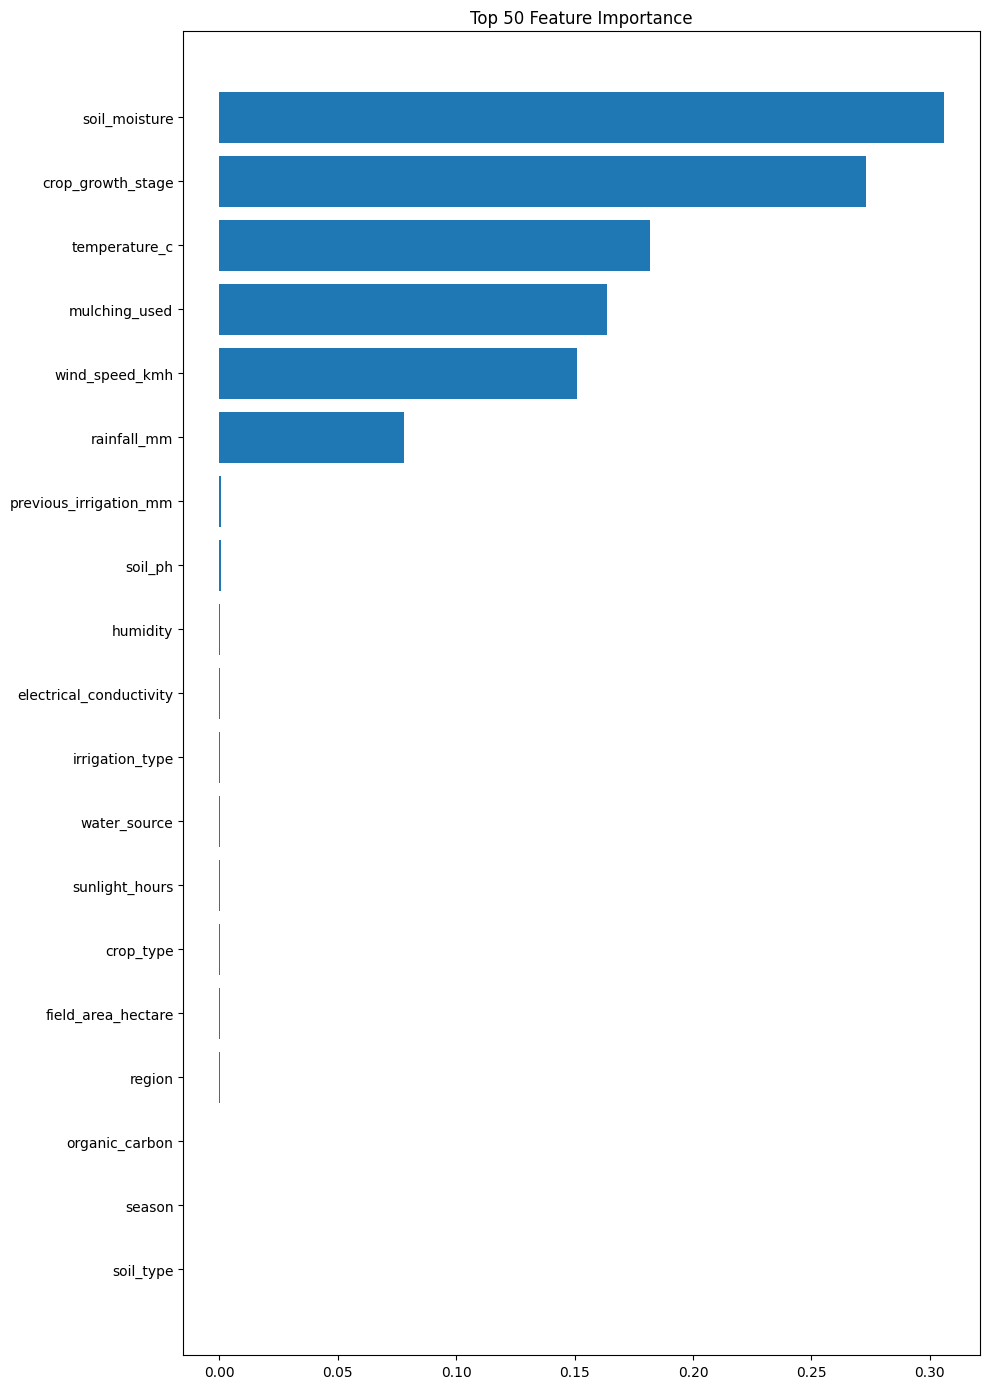

In [ ]:
fi = permutation_importance(
	model,
	X_valid,
	y_valid,
	scoring=agnostic_bacc_scorer,
	n_repeats=1,
	n_jobs=-1,
	random_state=config.SEED
)

fi_df = pd.DataFrame({
	"feature": X_valid.columns,
	"importance": fi.importances_mean
}).sort_values("importance", ascending=False).head(50)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
ax.set_title("Top 50 Feature Importance")
fig.tight_layout()
plt.show()

### Catboost Core

In [ ]:
M = X[config.BASE_NUM_COLS].max()
X = create_digit_features(X, M, config.BASE_NUM_COLS)
test_data = create_digit_features(test_data, M, config.BASE_NUM_COLS)

In [ ]:
DROP = [c for c in X.columns if X[c].nunique() == 1]
print(f"Dropping constant cols: {DROP}")
X.drop(columns=DROP, inplace=True)
test_data.drop(columns=DROP, inplace=True)

Dropping constant cols: ['soil_ph_digit1', 'soil_ph_digit2', 'soil_moisture_digit2', 'organic_carbon_digit1', 'organic_carbon_digit2', 'electrical_conductivity_digit1', 'electrical_conductivity_digit2', 'temperature_c_digit2', 'humidity_digit2', 'sunlight_hours_digit2', 'wind_speed_kmh_digit2', 'field_area_hectare_digit2']


In [ ]:
CATEGORY = config.BASE_CAT_COLS + [c for c in test_data.columns if 'digit' in c]

for c in tqdm(CATEGORY):
    freq = X[c].value_counts()
    mapping = {val: idx for idx, (val, count) in enumerate(freq[freq >= 5].items())}
    mapping_default = len(mapping)
    X[c] = X[c].map(lambda x: mapping.get(x, mapping_default))
    test_data[c] = test_data[c].map(lambda x: mapping.get(x, mapping_default))

FEATURES = CATEGORY + [c for c in config.BASE_NUM_COLS if c in test_data.columns]

  0%|          | 0/73 [00:00<?, ?it/s]

In [ ]:
"""for df in [X, test_data]:

    # ── Soil lookups (for relative_water_content + soil_moisture_deficit) ──
    FC  = {'sandy':0.18,'sandy_loam':0.25,'loam':0.35,'clay_loam':0.40,'clay':0.45}
    WP  = {'sandy':0.08,'sandy_loam':0.12,'loam':0.18,'clay_loam':0.22,'clay':0.27}

    df['_fc'] = df['soil_type'].map(FC).fillna(0.30)
    df['_wp'] = df['soil_type'].map(WP).fillna(0.15)

    # relative_water_content
    df['relative_water_content'] = (
        (df['soil_moisture'] / 100 - df['_wp']) /
        (df['_fc'] - df['_wp'] + 1e-5)
    ).clip(0, 1)

    # soil_moisture_deficit
    df['soil_moisture_deficit'] = df['_fc'] - df['soil_moisture'] / 100

    # ── Crop water demand per day ──
    KC = {'initial':0.40,'development':0.70,'mid_season':1.15,'late_season':0.75,'harvest':0.40}
    df['growth_stage_kc'] = df['crop_growth_stage'].map(KC).fillna(0.75)

    df['eto_hargreaves'] = (
        0.0023 * (df['temperature_c'] + 17.8)
        * (df['temperature_c'] ** 0.5)
        * df['sunlight_hours'] * 0.16
    )

    df['etc_crop_adjusted'] = df['eto_hargreaves'] * df['growth_stage_kc']

    # crop_water_demand_per_day
    df['crop_water_demand_per_day'] = (
        df['etc_crop_adjusted'] / (df['sunlight_hours'] + 1e-5)
    )

    # et_deficit
    df['et_deficit'] = df['etc_crop_adjusted'] - df['soil_moisture'] * 0.3

    # ── Water features ──
    IRR_EFF = {'drip':0.92,'sprinkler':0.78,'furrow':0.65,'flood':0.55}
    df['irrigation_efficiency_factor'] = df['irrigation_type'].map(IRR_EFF).fillna(0.70)

    df['effective_irr_delivered'] = (
        df['previous_irrigation_mm'] * df['irrigation_efficiency_factor']
    )

    EFF = {'sandy':0.75,'sandy_loam':0.80,'loam':0.85,'clay_loam':0.88,'clay':0.90}

    # effective_rainfall
    df['effective_rainfall'] = df['rainfall_mm'] * df['soil_type'].map(EFF).fillna(0.82)

    # total_water_input
    df['total_water_input'] = (
        df['effective_rainfall'] + df['effective_irr_delivered']
    )

    # rainfall_irrigation_gap
    df['rainfall_irrigation_gap'] = (
        df['previous_irrigation_mm'] - df['rainfall_mm']
    )

    # ── Mulch feature ──
    df['mulching_used'] = df['mulching_used'].map({'Yes': 1, 'No': 0})

    # mulch_moisture_retention
    df['mulch_moisture_retention'] = df['mulching_used'] * 0.25 * df['soil_moisture']

    # ── Cleanup ──
    df.drop(columns=[
        '_fc', '_wp',
        'growth_stage_kc', 'eto_hargreaves', 'etc_crop_adjusted',
        'irrigation_efficiency_factor', 'effective_irr_delivered'
    ], inplace=True)"""

In [ ]:
"""X, bigram_cols = create_cat_bigrams(X, config.BASE_CAT_COLS)
test_data, _ = create_cat_bigrams(test_data, config.BASE_CAT_COLS)

X, trigram_cols = create_cat_trigrams(X, config.BASE_CAT_COLS)
test_data, _ = create_cat_trigrams(test_data, config.BASE_CAT_COLS)

ngram_cols = bigram_cols + trigram_cols

for col in ngram_cols:
    combined = pd.concat([X[col], test_data[col]], axis=0).astype(str)

    labels, _ = pd.factorize(combined)

    n_train = len(X)

    X[col] = labels[:n_train]
    test_data[col] = labels[n_train:]"""

Added 28 bigram features
Added 28 bigram features
Added 56 trigram features
Added 56 trigram features


In [ ]:
# List of numerical and categorical features
num_cols = X.select_dtypes(include='number').columns.to_list()
cat_cols = X.select_dtypes(exclude='number').columns.to_list()

In [ ]:
EXP_NAME = "CATBOOST"
RUN_NAME = f"Catgbm_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_data), n_classes))
bacc_scores = []
ll_scores = []

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_text("\n".join(cat_cols), "artifacts/cat_cols.txt")
    mlflow.log_text("\n".join(num_cols), "artifacts/num_cols.txt")
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.CATBOOST_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
        X_test = test_data.copy()

		# ------ Pipeline -----
        train_pool = cb.Pool(data=X_train, label=y_train, cat_features=cat_cols, thread_count=-1)
        valid_pool = cb.Pool(data=X_valid, label=y_valid, cat_features=cat_cols, thread_count=-1)
        test_pool = cb.Pool(data=X_test, cat_features=cat_cols, thread_count=-1)

        model = cb.train(
            train_pool,
            config.CATBOOST_PARAMS,
            eval_set=valid_pool
		)

        # -------- FOLD RUN --------
        with mlflow.start_run(run_name=f"fold_{fold}", nested=True):

            oof_preds = model.predict(valid_pool, prediction_type='Probability')
            final_oof_preds[valid_idx] = oof_preds

            bacc = compute_bacc(y_valid, oof_preds)
            ll = compute_logloss(y_valid, oof_preds)

            bacc_scores.append(bacc)
            ll_scores.append(ll)

            print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

            test_preds = model.predict(test_pool, prediction_type='Probability')
            final_test_preds += test_preds / config.N_FOLDS

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)
    recall_per_class = compute_recall_per_class(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores),
        "recall_0": recall_per_class[0],
        "recall_1": recall_per_class[1],
        "recall_2": recall_per_class[2]
    }

    mlflow.log_metrics(metrics)
    
    if fold < config.N_FOLDS:
        del train_pool, valid_pool, test_pool, model, X_train, X_valid
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

In [ ]:
fi = permutation_importance(
	model,
	X_valid,
	y_valid,
	scoring=agnostic_bacc_scorer,
	n_repeats=1,
	n_jobs=-1,
	random_state=config.SEED
)

fi_df = pd.DataFrame({
	"feature": X_valid.columns,
	"importance": fi.importances_mean
}).sort_values("importance", ascending=False).head(50)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
ax.set_title("Top 50 Feature Importance")
fig.tight_layout()
plt.show()

###  XGBoost

In [709]:
top_cat_cols = ['crop_growth_stage', 'mulching_used']
top_num_cols = ['soil_moisture', 'temperature_c', 'wind_speed_kmh', 'rainfall_mm']
top_cols = ['soil_moisture', 'crop_growth_stage', 'temperature_c', 'mulching_used', 'wind_speed_kmh', 'rainfall_mm']

base = config.BASE_CAT_COLS + config.BASE_NUM_COLS

train_fe = X.copy()
test_fe = test_data.copy()
orig_fe = exog.copy()

In [710]:
# one-hot only for crop stage
for df in [train_fe, test_fe, orig_fe]:
    df['crop_growth_stage2'] = df['crop_growth_stage'].copy()
    df['mulching_used2'] = df['mulching_used'].copy()

train_fe = pd.get_dummies(train_fe, columns=['crop_growth_stage2'], dtype=int)
test_fe  = pd.get_dummies(test_fe,  columns=['crop_growth_stage2'], dtype=int)
orig_fe  = pd.get_dummies(orig_fe,  columns=['crop_growth_stage2'], dtype=int)

# map mulching_used
for df in [train_fe, test_fe, orig_fe]:
    df['mulching_used2'] = df['mulching_used'].map({'Yes': 1, 'No': 0})

In [711]:
def add_threshold_distances(df):
    df["soil_lt_25"] = (df["soil_moisture"] < 25).astype(int)
    df["wind_gt_10"] = (df["wind_speed_kmh"] > 10).astype(int)
    df["temp_gt_30"] = (df["temperature_c"] > 30).astype(int)
    df["rain_lt_300"] = (df["rainfall_mm"] < 300).astype(int)

    # domain
    df["moist_rain"] = df["soil_moisture"] / (df["rainfall_mm"] + 1)
    df["moist_temp"] = df["soil_moisture"] / (df["temperature_c"] + 1)
    df["moist_wind"] = df["soil_moisture"] / (df["wind_speed_kmh"] + 1)
    df["et_proxy"] = (df["temperature_c"] * df["wind_speed_kmh"] * df["sunlight_hours"]) / (df["humidity"] + 1)
    df["heat_stress"] = df["temperature_c"] * df["sunlight_hours"]
    df["drying_force"] = df["wind_speed_kmh"] * df["temperature_c"] / (df["humidity"] + 1)
    df["water_supply"] = df["rainfall_mm"] + df["previous_irrigation_mm"]
    df["water_deficit"] = df["soil_moisture"] - df["water_supply"] * 0.1
    df["soil_quality"] = df["organic_carbon"] / (df["electrical_conductivity"] + 0.1)
    df["moist_x_temp"] = df["soil_moisture"] * df["temperature_c"]
    df["wind_x_temp"] = df["wind_speed_kmh"] * df["temperature_c"]

    return df

train_fe = add_threshold_distances(train_fe)
test_fe = add_threshold_distances(test_fe)
orig_fe = add_threshold_distances(orig_fe)


def add_formula_features(df):
    df["high_score"] = (
        (df["soil_moisture"] < 25) * 2 +
        (df["rainfall_mm"] < 300) * 2 +
        (df["temperature_c"] > 30) * 1 +
        (df["wind_speed_kmh"] > 10) * 1
    )

    df["low_score"] = (
        (df["crop_growth_stage"].isin(["Harvest", "Sowing"])) * 2 +
        (df["mulching_used"] == "Yes") * 1
    )

    df["formula_score"] = df["high_score"] - df["low_score"]

    return df


train_fe = add_formula_features(train_fe)
test_fe = add_formula_features(test_fe)
orig_fe = add_formula_features(orig_fe)

In [712]:
train_fe, bigram_cols = create_cat_bigrams(train_fe, top_cat_cols)
test_fe, _ = create_cat_bigrams(test_fe, top_cat_cols)
orig_fe, _ = create_cat_bigrams(orig_fe, top_cat_cols)

for col in bigram_cols:
    combined = pd.concat([train_fe[col], test_fe[col], orig_fe[col]], axis=0, ignore_index=True).astype(str)
    
    # Factorize
    labels, uniques = pd.factorize(combined)
    n_train = len(train_fe)
    n_test = len(test_fe)
    
    train_fe[col] = labels[:n_train]
    test_fe[col]  = labels[n_train : n_train + n_test]
    orig_fe[col]  = labels[n_train + n_test :]

Added 1 bigram features
Added 1 bigram features
Added 1 bigram features


In [713]:
BIN_CAT_INT_COLS = []
for num_col in top_num_cols:
    bin_col = f"{num_col}_bin"
    train_fe[bin_col], bins = pd.qcut(train_fe[num_col], q=5, labels=False, 
                                           retbins=True, duplicates='drop')
    for df in [test_fe, orig_fe]:
        df[bin_col] = pd.cut(df[num_col], bins=bins, labels=False, 
                             include_lowest=True).fillna(0).astype(int)

    for cat_col in top_cat_cols:
        int_name = f"{num_col}_bin_{cat_col}_int"        
        for df in [train_fe, test_fe, orig_fe]:
            df[int_name] = df[bin_col].astype(str) + "_" + df[cat_col].astype(str)
        BIN_CAT_INT_COLS.append(int_name)

# droping numerical bins
for df in [train_fe, test_fe, orig_fe]:
    df.drop(columns=[f"{num_col}_bin" for num_col in top_num_cols], inplace=True)

for col in BIN_CAT_INT_COLS:
    codes, uniques = pd.factorize(train_fe[col])
    train_fe[col] = codes.astype('int')

    mapping = {val: i for i, val in enumerate(uniques)}
    
    test_fe[col] = test_fe[col].map(mapping)
    orig_fe[col] = orig_fe[col].map(mapping)

In [714]:
NUM_CAT_AGG_COLS = []

for cat_col in top_cat_cols:
    for num_col in top_num_cols:
        group_means = train_fe.groupby(cat_col)[num_col].mean()

        for df in [train_fe, test_fe, orig_fe]:
            # Group Average
            avg_name = f"{num_col}_avg_by_{cat_col}"
            df[avg_name] = df[cat_col].map(group_means).astype('float')
            
            # Difference
            diff_name = f"{num_col}_diff_{cat_col}"
            df[diff_name] = (df[num_col] - df[avg_name]).astype('float')
            
            # Ratio 
            ratio_name = f"{num_col}_ratio_{cat_col}"
            df[ratio_name] = (df[num_col] / (df[avg_name] + 1e-6)).astype('float')

            NUM_CAT_AGG_COLS.extend([avg_name, diff_name, ratio_name])

# Remove duplicates from the feature list
NUM_CAT_AGG_COLS = list(set(NUM_CAT_AGG_COLS))

In [715]:
round_config = {        
     'soil_moisture': [0, -1],
     'temperature_c': [-1],
     'rainfall_mm': [0, -1, -2, -3],
     'wind_speed_kmh': [0, -1]
}

digit_config = {        
     'soil_moisture': [-1, 0, 1, 2],
     'temperature_c': [-1, 0, 1, 2],
     'rainfall_mm': [-3, -2, -1, 0, 1, 2],
     'wind_speed_kmh': [-1, 0, 1, 2]
}


ROUND = []
for col, r_values in round_config.items():
    for r in r_values:
        feat = f"{col}_r{r}"
        for df in [train_fe, test_fe, orig_fe]:
            df[feat] = df[col].round(r)
        ROUND.append(feat)

DIGITS = []
for col, k_values in digit_config.items():
    for k in k_values:
        feat = f"{col}_d{k}"
        for df in [train_fe, test_fe, orig_fe]:
            df[feat] = ((df[col] * 10**k) % 10).astype(int)
        DIGITS.append(feat)

DECIMALS = []
for col in top_num_cols:
    feat = f"{col}_decimal"
    for df in [train_fe, test_fe, orig_fe]:
        df[feat] = (df[col] % 1).round(2)
    DECIMALS.append(feat)

BINS = []
for col in top_num_cols:
    feat = f"{col}_bin"
    train_fe[feat], bin_edges = pd.qcut(
        train_fe[col], q=10, labels=False, duplicates='drop', retbins=True
    )
    test_fe[col] = test_fe[col].clip(bin_edges[0], bin_edges[-1])
    test_fe[feat] = pd.cut(
        test_fe[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype(int)

    orig_fe[col] = orig_fe[col].clip(bin_edges[0], bin_edges[-1])
    orig_fe[feat] = pd.cut(
        orig_fe[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype(int)
    BINS.append(feat)

In [716]:
PAIRS = []
pair_cols = top_cols

train_len = train_fe.shape[0]
test_len = test_fe.shape[0]
orig_len = orig_fe.shape[0]
combined_len = train_len + test_len + orig_len

for col1, col2 in itertools.combinations(pair_cols, 2):
    name = f"{col1}__{col2}"

    # 1. Create temporary string series
    combined_str = pd.concat([
        train_fe[col1].astype(str) + '_' + train_fe[col2].astype(str),
        test_fe[col1].astype(str) + '_' + test_fe[col2].astype(str),
        orig_fe[col1].astype(str) + '_' + orig_fe[col2].astype(str)
    ], ignore_index=True)

    # 2. Factorize
    combined_codes, _ = pd.factorize(combined_str)
    
    # 3. Memory Cleanup
    del combined_str
    gc.collect()

    # 4. Cardinality Filter
    unique_count = len(np.unique(combined_codes))
    if unique_count > (combined_len // 2) or unique_count <= 1:
        del combined_codes
        continue

    # 5. Assign Integer Codes back to DataFrames
    train_fe[name] = combined_codes[:train_len]
    test_fe[name] = combined_codes[train_len : train_len + test_len]
    orig_fe[name] = combined_codes[train_len + test_len:]

    PAIRS.append(name)
    
    del combined_codes
    gc.collect()

In [717]:
for df in [train_fe, test_fe, orig_fe]:
    for col in config.BASE_CAT_COLS:
        df[col] = df[col].astype('category')

In [718]:
# making X and y for model training
X_train = train_fe.copy()
y_train = y.copy()
X_orig = orig_fe.drop(config.TARGET,axis=1)
y_orig = orig_fe[config.TARGET]
X_test = test_fe.copy()

#print shape
print(X_train.shape)
print(y_train.shape)
print(X_orig.shape)
print(y_orig.shape)
print(X_test.shape)

(630000, 119)
(630000,)
(10000, 119)
(10000,)
(270000, 119)


In [719]:
DROP_COLS = PAIRS + NUM_CAT_AGG_COLS + BIN_CAT_INT_COLS
te_features = X_train.columns.tolist()
ORIG_ROW_WEIGHT = 0.5

In [721]:
EXP_NAME = "XGBOOST"
RUN_NAME = f"xgbm_seed{config.SEED}_{RUN}"
N_BOOSTING_ROUNDS = 2600

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X_train), n_classes))
final_test_preds = np.zeros((len(X_test), n_classes))
bacc_scores = []
ll_scores = []

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_params({
        "seed": config.SEED,
        "n_folds": config.N_FOLDS,
        "n_cols": X_train.shape[1],
        'n_boosting_rounds': N_BOOSTING_ROUNDS,
        **config.XGB_PARAMS
    })

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        # 1. Split
        X_tr_real, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_real, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        y_val = y_val.values

        # 2. Combine with exog Data
        X_tr_combined = pd.concat([X_tr_real, X_orig], axis=0).reset_index(drop=True)
        y_tr_combined = np.concatenate([y_tr_real, y_orig])

        # 3. Target Encoding
        encoder = TargetEncoder(
            target_type="multiclass",
            smooth="auto",
            cv=5,
            random_state=config.SEED
        )

        X_tr_te = encoder.fit_transform(X_tr_combined[te_features], y_tr_combined)
        X_val_te = encoder.transform(X_val[te_features])
        X_test_te = encoder.transform(X_test[te_features])

        te_cols = []
        for col in te_features:
            for class_id in range(3):
                te_cols.append(f"TE_{col}_class{class_id}")

        X_tr_combined[te_cols] = X_tr_te
        X_val[te_cols] = X_val_te
        X_test_copy = X_test.copy()
        X_test_copy[te_cols] = X_test_te

        # 4. Drop unwanted columns
        X_tr_final = X_tr_combined.drop(columns=DROP_COLS)
        X_val_final = X_val.drop(columns=DROP_COLS)
        X_te_final = X_test_copy.drop(columns=DROP_COLS)

        # Sample weights
        sample_weights = compute_sample_weight("balanced", y_tr_combined)
        sample_weights[len(train_idx):] *= ORIG_ROW_WEIGHT

        # DMatrix
        dtrain = xgb.DMatrix(
            X_tr_final,
            label=y_tr_combined,
            weight=sample_weights,
            enable_categorical=True
        )
        dvalid = xgb.DMatrix(
            X_val_final,
            label=y_val,
            enable_categorical=True
        )
        dtest = xgb.DMatrix(X_te_final, enable_categorical=True)

        # Model Training
        model = xgb.train(
            params=config.XGB_PARAMS,
            dtrain=dtrain,
            num_boost_round=N_BOOSTING_ROUNDS,
            evals=[(dvalid, "valid")],
            verbose_eval=200
        )

        # -------- FOLD RUN --------
        oof_preds = model.predict(dvalid)
        final_oof_preds[val_idx] = oof_preds

        bacc = compute_bacc(y_val, oof_preds)
        ll = compute_logloss(y_val, oof_preds)

        bacc_scores.append(bacc)
        ll_scores.append(ll)

        mlflow.log_metric("fold_bacc", bacc, step=fold)
        mlflow.log_metric("fold_logloss", ll, step=fold)

        print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

        test_preds = model.predict(dtest)
        final_test_preds += test_preds / config.N_FOLDS

        del model, dtrain, dvalid, dtest, X_tr_final, X_val_final, X_te_final
        gc.collect()

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y_train, final_oof_preds)
    oof_logloss = compute_logloss(y_train, final_oof_preds)
    recall_per_class = compute_recall_per_class(y_train, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores),
        "recall_0": recall_per_class[0],
        "recall_1": recall_per_class[1],
        "recall_2": recall_per_class[2]
    }

    mlflow.log_metrics(metrics)

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

[0]	valid-mlogloss:1.03012
[200]	valid-mlogloss:0.06285
[400]	valid-mlogloss:0.05685
[600]	valid-mlogloss:0.05444
[800]	valid-mlogloss:0.05281
[1000]	valid-mlogloss:0.05172
[1200]	valid-mlogloss:0.05095
[1400]	valid-mlogloss:0.05029
[1600]	valid-mlogloss:0.04974
[1800]	valid-mlogloss:0.04931
[2000]	valid-mlogloss:0.04895
[2200]	valid-mlogloss:0.04865
[2400]	valid-mlogloss:0.04840
[2599]	valid-mlogloss:0.04818
Fold 1 | Balanced Acc: 0.97722 | LogLoss: 0.04818
[0]	valid-mlogloss:1.03022
[200]	valid-mlogloss:0.06415
[400]	valid-mlogloss:0.05765
[600]	valid-mlogloss:0.05501
[800]	valid-mlogloss:0.05346
[1000]	valid-mlogloss:0.05233
[1200]	valid-mlogloss:0.05154
[1400]	valid-mlogloss:0.05089
[1600]	valid-mlogloss:0.05033
[1800]	valid-mlogloss:0.04989
[2000]	valid-mlogloss:0.04952
[2200]	valid-mlogloss:0.04922
[2400]	valid-mlogloss:0.04896
[2599]	valid-mlogloss:0.04872
Fold 2 | Balanced Acc: 0.97795 | LogLoss: 0.04872
[0]	valid-mlogloss:1.03026
[200]	valid-mlogloss:0.06490
[400]	valid-mloglo

c:\Users\aryan\miniconda3\envs\kaggle\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


Saving file to: artifacts\oof\xgbm_seed42_v1_oof_proba.csv
Saving file to: artifacts\test_proba\xgbm_seed42_v1_test_proba.csv


### Resnet

In [326]:
# List of numerical and categorical features
num_cols = X.select_dtypes(include='number').columns.to_list()
cat_cols = X.select_dtypes(exclude='number').columns.to_list()

In [ ]:
EXP_NAME = "Resnet_RTDL_D"
RUN_NAME = f"resnet_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_data), n_classes))
feature_importance = []
bacc_scores = []
ll_scores = []

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_text("\n".join(cat_cols), "artifacts/cat_cols.txt")
    mlflow.log_text("\n".join(num_cols), "artifacts/num_cols.txt")
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.Resnet_RTDL_D_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
        
		# -------- MODEL --------
        model = Resnet_RTDL_D_Classifier(**config.Resnet_RTDL_D_PARAMS)
        
        model.fit(X_train, y_train, X_valid, y_valid)

        # -------- FOLD RUN --------
        with mlflow.start_run(run_name=f"fold_{fold}", nested=True):

            oof_preds = model.predict_proba(X_valid)
            oof_preds = oof_preds / oof_preds.sum(axis=1, keepdims=True) # To fix UserWarning: The y_prob values do not sum to one

            final_oof_preds[valid_idx] = oof_preds

            bacc = compute_bacc(y_valid, oof_preds)
            ll = compute_logloss(y_valid, oof_preds)

            bacc_scores.append(bacc)
            ll_scores.append(ll)

            print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

            test_preds = model.predict_proba(test_data)
            test_preds = test_preds / test_preds.sum(axis=1, keepdims=True) # To fix UserWarning: The y_prob values do not sum to one

            final_test_preds += test_preds / config.N_FOLDS

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)
    recall_per_class = compute_recall_per_class(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores),
        "recall_0": recall_per_class[0],
        "recall_1": recall_per_class[1],
        "recall_2": recall_per_class[2]
    }

    mlflow.log_metrics(metrics)
    
    if fold < 5:
        del model, X_train, X_valid, y_train, y_valid
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

In [ ]:
fi = permutation_importance(
	model,
	X_valid,
	y_valid,
	scoring=agnostic_bacc_scorer,
	n_repeats=1,
	n_jobs=-1,
	random_state=config.SEED
)

fi_df = pd.DataFrame({
	"feature": X_valid.columns,
	"importance": fi.importances_mean
}).sort_values("importance", ascending=False).head(50)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
ax.set_title("Top 50 Feature Importance")
fig.tight_layout()
plt.show()

### RealMLP

In [ ]:
"""M = X[config.BASE_NUM_COLS].max()
X = create_digit_features(X, M, config.BASE_NUM_COLS)
test_data = create_digit_features(test_data, M, config.BASE_NUM_COLS)

DROP = [c for c in X.columns if X[c].nunique() == 1]
print(f"Dropping constant cols: {DROP}")
X.drop(columns=DROP, inplace=True)
test_data.drop(columns=DROP, inplace=True)

CATEGORY = config.BASE_CAT_COLS + [c for c in test_data.columns if 'digit' in c]

for c in tqdm(CATEGORY):
    freq = X[c].value_counts()
    mapping = {val: idx for idx, (val, count) in enumerate(freq[freq >= 5].items())}
    mapping_default = len(mapping)
    X[c] = X[c].map(lambda x: mapping.get(x, mapping_default))
    test_data[c] = test_data[c].map(lambda x: mapping.get(x, mapping_default))

FEATURES = CATEGORY + [c for c in config.BASE_NUM_COLS if c in test_data.columns]"""

In [212]:
X = train.drop(['id', 'irrigation_need'], axis=1)
y = train.irrigation_need
classes = np.unique(y)

test_final = test.drop('id', axis=1)

In [214]:
EXP_NAME = "REALMLP"
RUN_NAME = f"realMLP_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_final), n_classes))
feature_importance = []
bacc_scores = []
ll_scores = []
X_test = test_final.copy()

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.RealMLP_TD_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
        
        te = ColumnTransformer(
            transformers=[
                ("te", TargetEncoder(target_type='multiclass', cv=5, shuffle=True, random_state=config.SEED), TE_columns)
			], remainder='passthrough'
		).set_output(transform='pandas')
        
        X_train_te = te.fit_transform(X_train, y_train)
        X_valid_te = te.transform(X_valid)
        X_test_te = te.transform(X_test)
		
		# -------- MODEL --------
        model = RealMLP_TD_Classifier(**config.RealMLP_TD_PARAMS)
        model.fit(X_train_te, y_train, X_valid_te, y_valid)

        # -------- Inference --------
        oof_preds = model.predict_proba(X_valid_te)
        oof_preds = oof_preds / oof_preds.sum(axis=1, keepdims=True) # To fix UserWarning: The y_prob values do not sum to one

        final_oof_preds[valid_idx] = oof_preds

        bacc = compute_bacc(y_valid, oof_preds)
        ll = compute_logloss(y_valid, oof_preds)

        bacc_scores.append(bacc)
        ll_scores.append(ll)

        print("="*80)
        print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")
        print("="*80)

        test_preds = model.predict_proba(X_test_te)
        test_preds = test_preds / test_preds.sum(axis=1, keepdims=True) # To fix UserWarning: The y_prob values do not sum to one

        final_test_preds += test_preds / config.N_FOLDS

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores)
    }

    mlflow.log_metrics(metrics)
    
    if fold < 5:
        del model, X_train, X_valid, y_train, y_valid, X_train_te, X_valid_te
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))

Columns classified as continuous: ['te__soil_moisture-crop_growth_stage_0.0', 'te__soil_moisture-crop_growth_stage_1.0', 'te__soil_moisture-crop_growth_stage_2.0', 'te__soil_moisture-mulching_used_0.0', 'te__soil_moisture-mulching_used_1.0', 'te__soil_moisture-mulching_used_2.0', 'te__crop_growth_stage-temperature_c_0.0', 'te__crop_growth_stage-temperature_c_1.0', 'te__crop_growth_stage-temperature_c_2.0', 'te__crop_growth_stage-mulching_used_0.0', 'te__crop_growth_stage-mulching_used_1.0', 'te__crop_growth_stage-mulching_used_2.0', 'te__crop_growth_stage-wind_speed_kmh_0.0', 'te__crop_growth_stage-wind_speed_kmh_1.0', 'te__crop_growth_stage-wind_speed_kmh_2.0', 'te__crop_growth_stage-rainfall_mm_0.0', 'te__crop_growth_stage-rainfall_mm_1.0', 'te__crop_growth_stage-rainfall_mm_2.0', 'te__temperature_c-mulching_used_0.0', 'te__temperature_c-mulching_used_1.0', 'te__temperature_c-mulching_used_2.0', 'te__mulching_used-wind_speed_kmh_0.0', 'te__mulching_used-wind_speed_kmh_1.0', 'te__mulc

### Extratrees

In [140]:
def add_threshold_distances(df):
    df["soil_lt_25"] = (df["soil_moisture"] < 25).astype(int)
    df["wind_gt_10"] = (df["wind_speed_kmh"] > 10).astype(int)
    df["temp_gt_30"] = (df["temperature_c"] > 30).astype(int)
    df["rain_lt_300"] = (df["rainfall_mm"] < 300).astype(int)

    # domain
    df["moist_rain"] = df["soil_moisture"] / (df["rainfall_mm"] + 1)
    df["moist_temp"] = df["soil_moisture"] / (df["temperature_c"] + 1)
    df["moist_wind"] = df["soil_moisture"] / (df["wind_speed_kmh"] + 1)
    df["et_proxy"] = (df["temperature_c"] * df["wind_speed_kmh"] * df["sunlight_hours"]) / (df["humidity"] + 1)
    df["heat_stress"] = df["temperature_c"] * df["sunlight_hours"]
    df["drying_force"] = df["wind_speed_kmh"] * df["temperature_c"] / (df["humidity"] + 1)
    df["water_supply"] = df["rainfall_mm"] + df["previous_irrigation_mm"]
    df["water_deficit"] = df["soil_moisture"] - df["water_supply"] * 0.1
    df["soil_quality"] = df["organic_carbon"] / (df["electrical_conductivity"] + 0.1)
    df["moist_x_temp"] = df["soil_moisture"] * df["temperature_c"]
    df["wind_x_temp"] = df["wind_speed_kmh"] * df["temperature_c"]

    return df

X = add_threshold_distances(X)
test_data = add_threshold_distances(test_data)
exog = add_threshold_distances(exog)


def add_formula_features(df):
    df["high_score"] = (
        (df["soil_moisture"] < 25) * 2 +
        (df["rainfall_mm"] < 300) * 2 +
        (df["temperature_c"] > 30) * 1 +
        (df["wind_speed_kmh"] > 10) * 1
    )

    df["low_score"] = (
        (df["crop_growth_stage"].isin(["Harvest", "Sowing"])) * 2 +
        (df["mulching_used"] == "Yes") * 1
    )

    df["formula_score"] = df["high_score"] - df["low_score"]

    return df


X = add_formula_features(X)
test_data = add_formula_features(test_data)
exog = add_formula_features(exog)

In [141]:
# List of numerical and categorical features
num_cols = X.select_dtypes(include='number').columns.to_list()
cat_cols = X.select_dtypes(exclude='number').columns.to_list()

In [ ]:
EXP_NAME = "EXTRATREES"
RUN_NAME = f"Etree_seed{config.SEED}_{RUN}"

skf = StratifiedKFold(
    n_splits=config.N_FOLDS,
    shuffle=True,
    random_state=config.SEED
)

final_oof_preds = np.zeros((len(X), n_classes))
final_test_preds = np.zeros((len(test_data), n_classes))
feature_importance = []
bacc_scores = []
ll_scores = []
X_test = test_data.copy()

mlflow.set_experiment(EXP_NAME)

with mlflow.start_run(run_name=RUN_NAME):

    # -------- STATIC LOGS --------
    mlflow.log_text("\n".join(cat_cols), "artifacts/cat_cols.txt")
    mlflow.log_text("\n".join(num_cols), "artifacts/num_cols.txt")
    mlflow.log_params({
		"seed": config.SEED,
		"n_folds": config.N_FOLDS,
		"n_cols": X.shape[1],
		**config.EXTRATREES_PARAMS
	})

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]

        # -------- PIPELINE --------
        te = ColumnTransformer(
               transformers=[
                    ('encoder', TargetEncoder(target_type='multiclass', cv=5, shuffle=True, random_state=config.SEED), cat_cols)
			   ], remainder='passthrough'
		).set_output(transform='pandas')
        
        X_train_te = te.fit_transform(X_train, y_train)
        X_valid_te = te.transform(X_valid)
        X_test_te = te.transform(X_test)
        model = ExtraTreesClassifier(**config.EXTRATREES_PARAMS)

        model.fit(X_train_te, y_train)

        oof_preds = model.predict_proba(X_valid_te)
        final_oof_preds[valid_idx] = oof_preds

        bacc = compute_bacc(y_valid, oof_preds)
        ll = compute_logloss(y_valid, oof_preds)

        bacc_scores.append(bacc)
        ll_scores.append(ll)

        print(f"Fold {fold} | Balanced Acc: {bacc:.5f} | LogLoss: {ll:.5f}")

        test_preds = model.predict_proba(X_test_te)
        final_test_preds += test_preds / config.N_FOLDS

    # -------- FINAL METRICS --------
    oof_bacc = compute_bacc(y, final_oof_preds)
    oof_logloss = compute_logloss(y, final_oof_preds)

    metrics = {
        "oof_bacc": oof_bacc,
        "oof_logloss": oof_logloss,
        "std_bacc": np.std(bacc_scores),
        "std_logloss": np.std(ll_scores)
    }

    mlflow.log_metrics(metrics)
    
    if fold < config.N_FOLDS:
        del model, X_train, X_valid, y_train, y_valid, X_train_te, X_valid_te, X_test, X_test_te
        gc.collect()

# -------- SAVE FILES --------
oof_df = pd.DataFrame(final_oof_preds, columns=[str(c) for c in classes])
oof_df.insert(0, "id", train_ids)
save_csv_file(oof_df, os.path.join(config.OOF_DIR, f"{RUN_NAME}_oof_proba.csv"))

test_df = pd.DataFrame(final_test_preds, columns=[str(c) for c in classes])
test_df.insert(0, "id", test_ids)
save_csv_file(test_df, os.path.join(config.TEST_PROBA_DIR, f"{RUN_NAME}_test_proba.csv"))